In [1]:
objective = "Classification: Survived (Yes/No)"
success_criteria = "Accuracy > 80%"
constraints = "Missing values and limited features"
print(objective)
print(success_criteria)
print(constraints)

Classification: Survived (Yes/No)
Accuracy > 80%
Missing values and limited features


In [2]:
import seaborn as sns
df = sns.load_dataset("titanic")
print(df.head())
print(df.shape)


   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
(891, 15)


In [3]:
import pandas as pd
df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
df.drop_duplicates(inplace=True)
df = pd.get_dummies(
    df,
    columns=['sex','class','embarked'],
    drop_first=True
)
df['family_size'] = df['sibsp'] + df['parch']
print(df.head())

   survived  pclass   age  sibsp  parch     fare    who  adult_male deck  \
0         0       3  22.0      1      0   7.2500    man        True  NaN   
1         1       1  38.0      1      0  71.2833  woman       False    C   
2         1       3  26.0      0      0   7.9250  woman       False  NaN   
3         1       1  35.0      1      0  53.1000  woman       False    C   
4         0       3  35.0      0      0   8.0500    man        True  NaN   

   embark_town alive  alone  sex_male  class_Second  class_Third  embarked_Q  \
0  Southampton    no  False      True         False         True       False   
1    Cherbourg   yes  False     False         False        False       False   
2  Southampton   yes   True     False         False         True       False   
3  Southampton   yes  False     False         False        False       False   
4  Southampton    no   True      True         False         True       False   

   embarked_S  family_size  
0        True            1  
1   

C:\Users\kondr\AppData\Local\Temp\ipykernel_22156\13670876.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['age'].fillna(df['age'].median(), inplace=True)
C:\Users\kondr\AppData\Local\Temp\ipykernel_22156\13670876.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment u

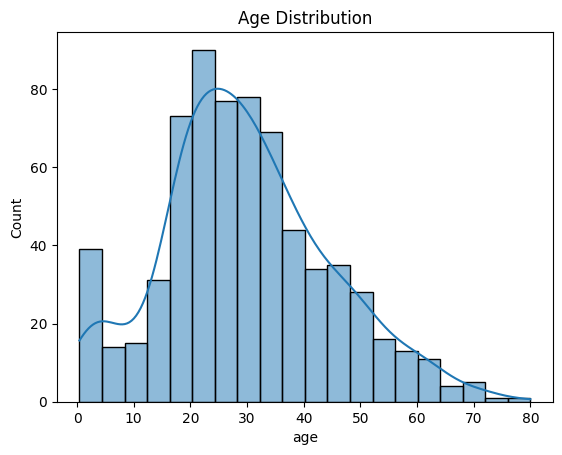

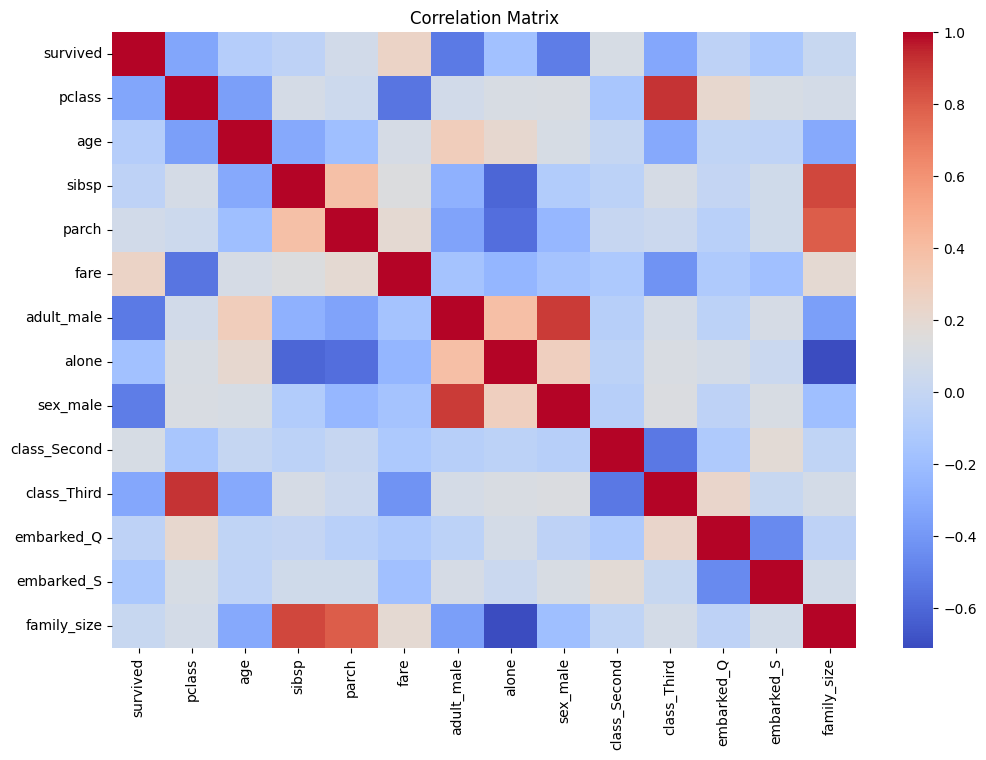

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
X = df.drop('survived', axis=1)
y = df['survived']
X = X.select_dtypes(include=['int64','float64','bool'])
X = X.fillna(X.mean(numeric_only=True)).fillna(0)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall   :", recall_score(y_test,y_pred))

Accuracy : 0.802547770700637
Precision: 0.796875
Recall   : 0.7391304347826086
